# HATR cross-framework — Performance computazionale

Confronto del costo computazionale di HATR in River (Python) e CapyMOA (JVM via JNI): tempo di training, inferenza, throughput e crescita della dimensione modello.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    SIZEOF_JAR = os.path.expanduser(
        "~/.m2/repository/com/github/fracpete/sizeofag/1.1.0/sizeofag-1.1.0.jar")
    if os.path.exists(SIZEOF_JAR):
        os.environ["CAPYMOA_JVM_ARGS"] = (
            f"-Xmx8g -Xss10M -javaagent:{SIZEOF_JAR} "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
            "-XX:ErrorFile=/dev/null"
        )
    else:
        os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression
import psutil
from pympler import asizeof

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [2]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 17000, 5000

import urllib.request, gzip, shutil

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), 'data'))
os.makedirs(DATA_DIR, exist_ok=True)

_ELEC_PATH = os.path.join(DATA_DIR, 'electricity.arff')
_ELEC_URL  = 'https://www.dropbox.com/scl/fi/p7btran9xdas20neva917/electricity.arff.gz?rlkey=xt8hc6542b8wr01eitcw7mwpz&st=paqojdax&dl=1'
if not os.path.exists(_ELEC_PATH):
    print('Downloading electricity.arff...')
    _gz = _ELEC_PATH + '.gz'
    urllib.request.urlretrieve(_ELEC_URL, _gz)
    with gzip.open(_gz, 'rb') as _f_in, open(_ELEC_PATH, 'wb') as _f_out:
        shutil.copyfileobj(_f_in, _f_out)
    os.remove(_gz)
    print('Done.')

datasets = {}
datasets["Synthetic"] = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"] = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"] = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"] = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)
datasets["HyperFast"] = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=5, magnitude_of_change=0.1,
                         noise_percentage=10),
    MAX_INSTANCES)
datasets["FriedDrift"] = utils.make_fried_drift(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["RBFReg"] = utils.make_rbf_regression(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["ElectricityDemand"] = utils.load_electricity_demand(
    os.path.join(DATA_DIR, 'electricity.arff'), max_instances=MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<20} n={len(X):>6}  feat={X.shape[1]:>2}  y\u2208[{y.min():.2f}, {y.max():.2f}]")

Synthetic            n= 17000  feat= 5  y∈[-14.29, 15.55]
Bike                 n= 17000  feat=12  y∈[1.00, 977.00]
Fried                n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper                n= 17000  feat=10  y∈[93.98, 677.42]
HyperFast            n= 17000  feat=10  y∈[-4117.78, 11925.45]
FriedDrift           n= 17000  feat=10  y∈[-0.69, 30.15]
RBFReg               n= 17000  feat=10  y∈[-13.18, 16.44]
ElectricityDemand    n= 17000  feat= 7  y∈[0.00, 0.94]


## Parametri

In [3]:
BASE = dict(grace_period=50, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=500, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.0001, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True

## Esecuzione

In [4]:
SAMPLE_EVERY = 500
PERF_CONFIG  = "default (adaptive, bootstrap)"
cfg = CONFIGS[PERF_CONFIG]

# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', cfg, BASE, schema=_w_schema, scale=SCALE)

rows = []
for ds_name, (X, y, schema) in datasets.items():
    n = len(X)
    _, r_model, rt_p, rt_t, _ = utils.prequential_eval(X, y, 'river', cfg, BASE, time_algo=True)
    _, c_learner, ct_p, ct_t, _ = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, time_algo=True)
    r_mb = utils.river_model_mb(r_model)
    c_mb = utils.capy_model_mb(c_learner)
    rows.append(dict(dataset=ds_name, framework="River", n=n,
                     train_s=rt_t, predict_s=rt_p, total_s=rt_t + rt_p,
                     inst_per_s=n / (rt_t + rt_p), model_MB=r_mb))
    rows.append(dict(dataset=ds_name, framework="CapyMOA", n=n,
                     train_s=ct_t, predict_s=ct_p, total_s=ct_t + ct_p,
                     inst_per_s=n / (ct_t + ct_p), model_MB=c_mb))
    print(f"  {ds_name:<10} River {rt_t+rt_p:6.2f}s {r_mb:.3f} MB  |  CapyMOA {ct_t+ct_p:6.2f}s {c_mb:.4f} MB")

perf = pd.DataFrame(rows)
speedup = (perf[perf.framework == "CapyMOA"].set_index("dataset")["inst_per_s"] /
           perf[perf.framework == "River"].set_index("dataset")["inst_per_s"])
perf["speedup_vs_river"] = perf["dataset"].map(speedup)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
perf

  Synthetic  River   2.15s 4.448 MB  |  CapyMOA   0.49s 1.0540 MB
  Bike       River   2.39s 0.994 MB  |  CapyMOA   0.70s 0.2522 MB
  Fried      River   4.54s 4.884 MB  |  CapyMOA   0.88s 0.4094 MB
  Hyper      River   4.61s 1.593 MB  |  CapyMOA   0.77s 0.7203 MB
  HyperFast  River   4.36s 1.121 MB  |  CapyMOA   0.81s 0.1707 MB
  FriedDrift River   4.20s 6.045 MB  |  CapyMOA   0.87s 0.8802 MB
  RBFReg     River   4.38s 6.639 MB  |  CapyMOA   0.74s 1.3958 MB
  ElectricityDemand River   1.69s 0.455 MB  |  CapyMOA   0.44s 0.0680 MB


,dataset,framework,n,train_s,predict_s,total_s,inst_per_s,model_MB,speedup_vs_river
0,Synthetic,River,17000,2.0273,0.1204,2.1476,7915.7299,4.4476,4.4220
1,Synthetic,CapyMOA,17000,0.3871,0.0986,0.4857,35003.6399,1.0540,4.4220
2,Bike,River,17000,2.2900,0.1003,2.3903,7112.2229,0.9939,3.4281
3,Bike,CapyMOA,17000,0.5973,0.1000,0.6972,24381.6440,0.2522,3.4281
4,Fried,River,17000,4.4065,0.1321,4.5386,3745.6555,4.8840,5.1825
5,Fried,CapyMOA,17000,0.7766,0.0991,0.8757,19412.0365,0.4094,5.1825
6,Hyper,River,17000,4.5001,0.1089,4.6090,3688.4548,1.5925,6.0073
7,Hyper,CapyMOA,17000,0.6671,0.1001,0.7672,22157.4858,0.7203,6.0073
8,HyperFast,River,17000,4.2725,0.0896,4.3620,3897.2565,1.1211,5.3538
9,HyperFast,CapyMOA,17000,0.7182,0.0966,0.8148,20865.2784,0.1707,5.3538


## Grafici

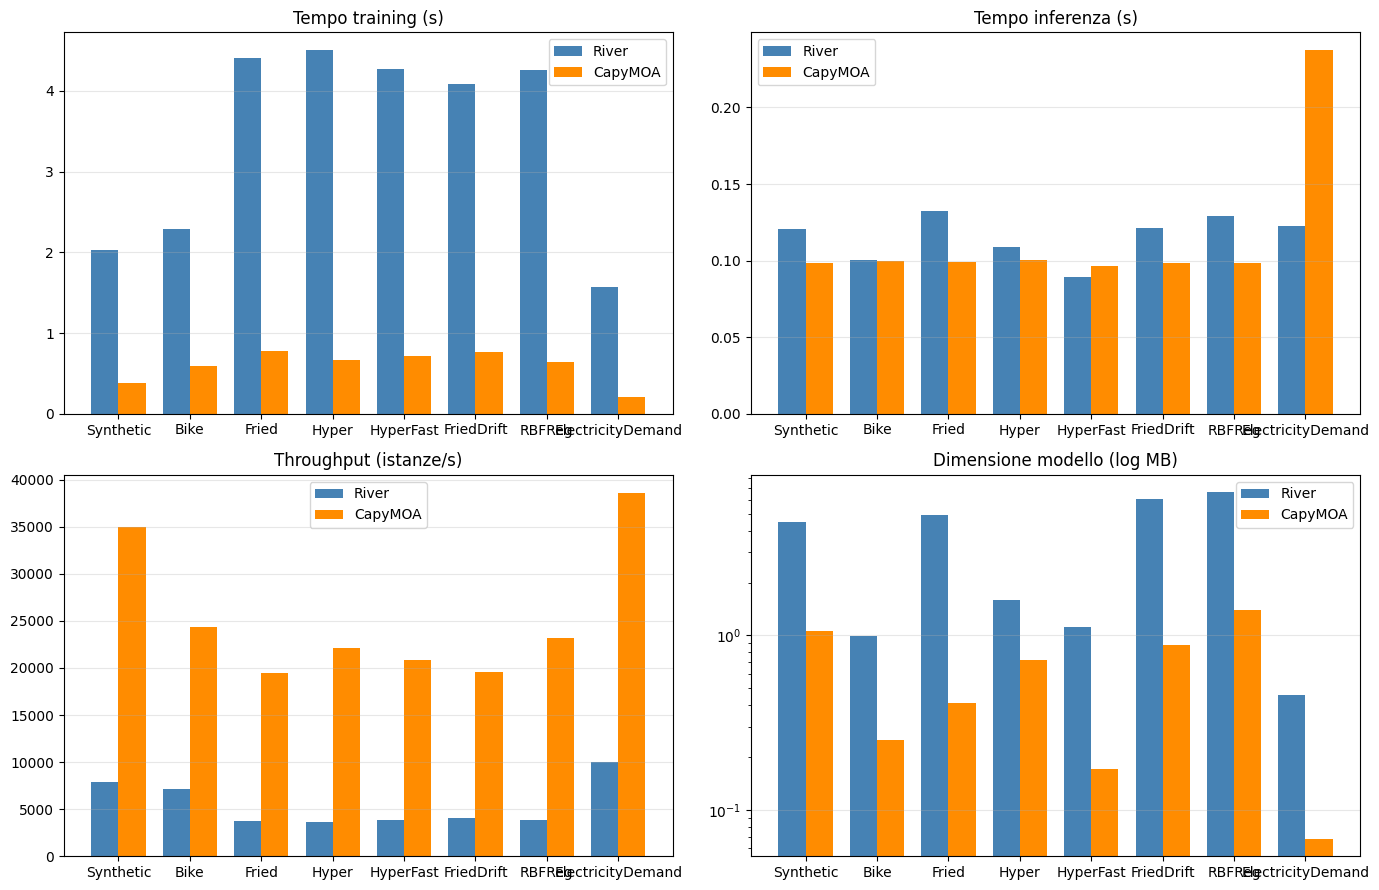

          dataset framework  train_s  predict_s  inst_per_s  model_MB  speedup_vs_river
        Synthetic     River   2.0273     0.1204   7915.7299    4.4476            4.4220
        Synthetic   CapyMOA   0.3871     0.0986  35003.6399    1.0540            4.4220
             Bike     River   2.2900     0.1003   7112.2229    0.9939            3.4281
             Bike   CapyMOA   0.5973     0.1000  24381.6440    0.2522            3.4281
            Fried     River   4.4065     0.1321   3745.6555    4.8840            5.1825
            Fried   CapyMOA   0.7766     0.0991  19412.0365    0.4094            5.1825
            Hyper     River   4.5001     0.1089   3688.4548    1.5925            6.0073
            Hyper   CapyMOA   0.6671     0.1001  22157.4858    0.7203            6.0073
        HyperFast     River   4.2725     0.0896   3897.2565    1.1211            5.3538
        HyperFast   CapyMOA   0.7182     0.0966  20865.2784    0.1707            5.3538
       FriedDrift     River   4.

In [5]:
ds_order = list(datasets.keys())
def vals(metric, fw):
    return [perf[(perf.dataset == d) & (perf.framework == fw)][metric].values[0] for d in ds_order]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [
    ("train_s",    "Tempo training (s)",         False),
    ("predict_s",  "Tempo inferenza (s)",         False),
    ("inst_per_s", "Throughput (istanze/s)",      False),
    ("model_MB",   "Dimensione modello (log MB)", True),
]
for ax, (metric, title, log_scale) in zip(axes.ravel(), panels):
    rv, cm = vals(metric, "River"), vals(metric, "CapyMOA")
    xpos = np.arange(len(ds_order)); wbar = 0.38
    ax.bar(xpos - wbar/2, rv, wbar, label="River",   color="steelblue")
    ax.bar(xpos + wbar/2, cm, wbar, label="CapyMOA", color="darkorange")
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks(xpos); ax.set_xticklabels(ds_order); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(perf[["dataset", "framework", "train_s", "predict_s", "inst_per_s",
            "model_MB", "speedup_vs_river"]].to_string(index=False))

## Crescita dimensione modello

Synthetic: River 3.283 MB | CapyMOA 0.6088 MB
Bike: River 0.764 MB | CapyMOA 0.1746 MB
Fried: River 6.935 MB | CapyMOA 1.0847 MB
Hyper: River 0.586 MB | CapyMOA 0.0880 MB
HyperFast: River 0.642 MB | CapyMOA 0.0954 MB
FriedDrift: River 1.970 MB | CapyMOA 0.3042 MB
RBFReg: River 11.495 MB | CapyMOA 1.7819 MB
ElectricityDemand: River 0.454 MB | CapyMOA 0.1208 MB


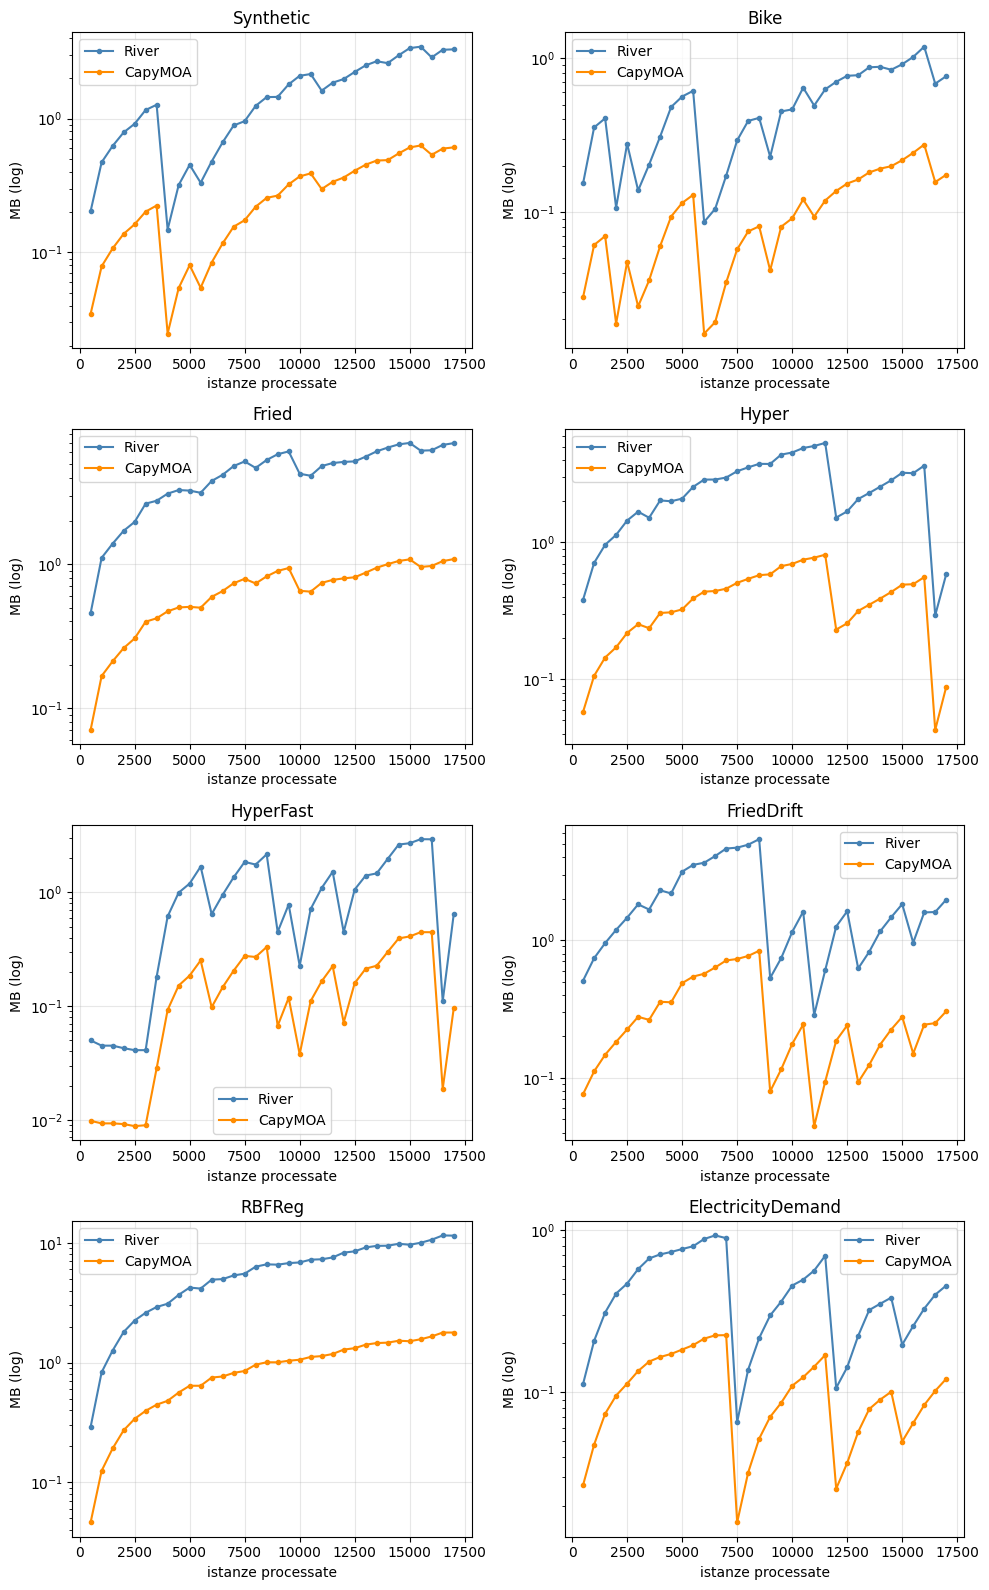

In [6]:
cfg = CONFIGS["deterministic (mean, no-bootstrap)"]
traces = {}
for ds_name, (X, y, schema) in datasets.items():
    _, _, _, _, tr_r = utils.prequential_eval(X, y, 'river', cfg, BASE, scale=SCALE, sample_every=SAMPLE_EVERY)
    _, _, _, _, tr_c = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, scale=SCALE, sample_every=SAMPLE_EVERY)
    traces[ds_name] = {"River": tr_r, "CapyMOA": tr_c}
    print(f"{ds_name}: River {tr_r[-1]['model_MB']:.3f} MB | CapyMOA {tr_c[-1]['model_MB']:.4f} MB")

colors  = {"River": "steelblue", "CapyMOA": "darkorange"}
ds_list = list(datasets.keys())

ncols = 2
nrows = -(-len(ds_list) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
axes = axes.flatten()
for ax, ds_name in zip(axes, ds_list):
    for fw in ("River", "CapyMOA"):
        t  = traces[ds_name][fw]
        ns = [p["n"]        for p in t]
        vs = [p["model_MB"] for p in t]
        ax.plot(ns, vs, label=fw, color=colors[fw], marker="o", markersize=3)
    ax.set_yscale("log")
    ax.set_title(ds_name)
    ax.set_xlabel("istanze processate")
    ax.set_ylabel("MB (log)")
    ax.legend(); ax.grid(alpha=0.3)

for ax in axes[len(ds_list):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()